# Task 1: Exploring and Visualizing the Iris Dataset

## Introduction & Problem Statement
The Iris dataset is one of the most well-known datasets in machine learning. It contains measurements of 150 iris flowers from three species: *Iris setosa*, *Iris versicolor*, and *Iris virginica*.

**Goal:** Load the dataset, inspect its structure, and create meaningful visualizations to understand the relationships between features and spot differences between species.

**Features:**
- `sepal_length` — length of the sepal (cm)
- `sepal_width`  — width of the sepal (cm)
- `petal_length` — length of the petal (cm)
- `petal_width`  — width of the petal (cm)
- `species`      — type of iris flower (target)

In [1]:
# ─── Import Libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent visual style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (9, 5)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load the Dataset

In [2]:
# Load Iris dataset directly from seaborn's built-in datasets
df = sns.load_dataset('iris')

print('Dataset loaded!')
print(f'Shape: {df.shape}')   # (rows, columns)

Dataset loaded!
Shape: (150, 5)


## 2. Dataset Structure & Inspection

In [3]:
# Display column names
print('Columns:', df.columns.tolist())

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [4]:
# First 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
# Statistical summary of numeric columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# Check class distribution
print('Species counts:')
print(df['species'].value_counts())

Species counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [8]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


## 3. Exploratory Data Analysis (EDA)
### 3a. Scatter Plot — Relationship Between Variables

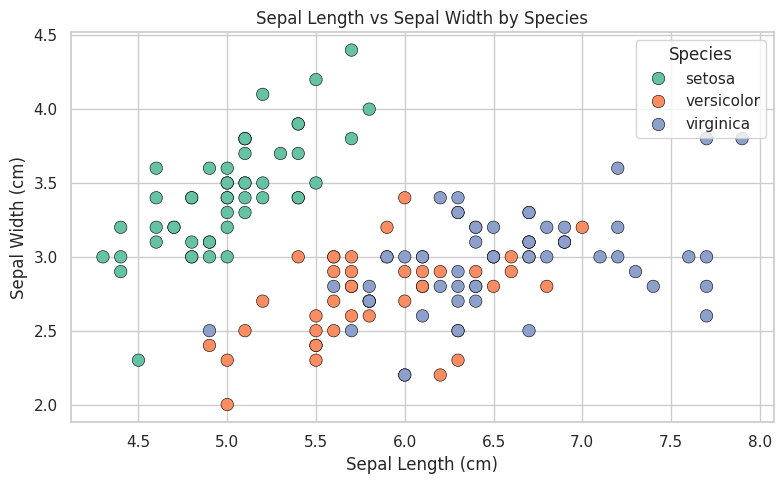

In [9]:
# Scatter plot: Sepal Length vs Sepal Width, colored by species
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width',
                hue='species', s=80, edgecolor='black', linewidth=0.4)
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

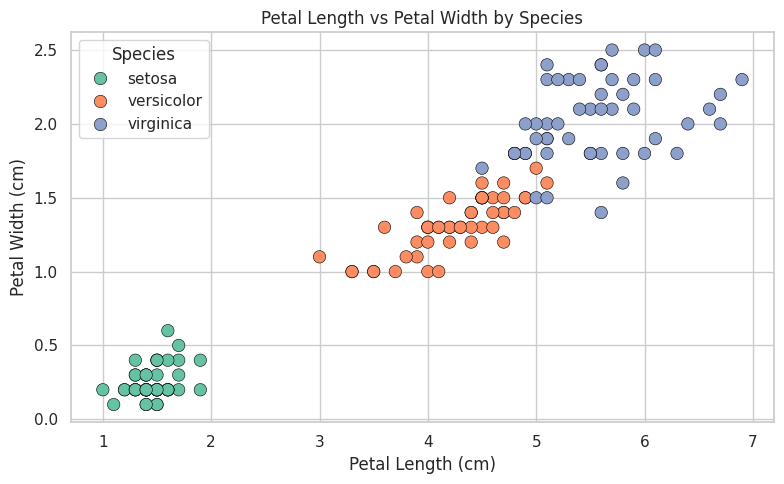

In [10]:
# Scatter plot: Petal Length vs Petal Width (usually better separation)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', s=80, edgecolor='black', linewidth=0.4)
plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

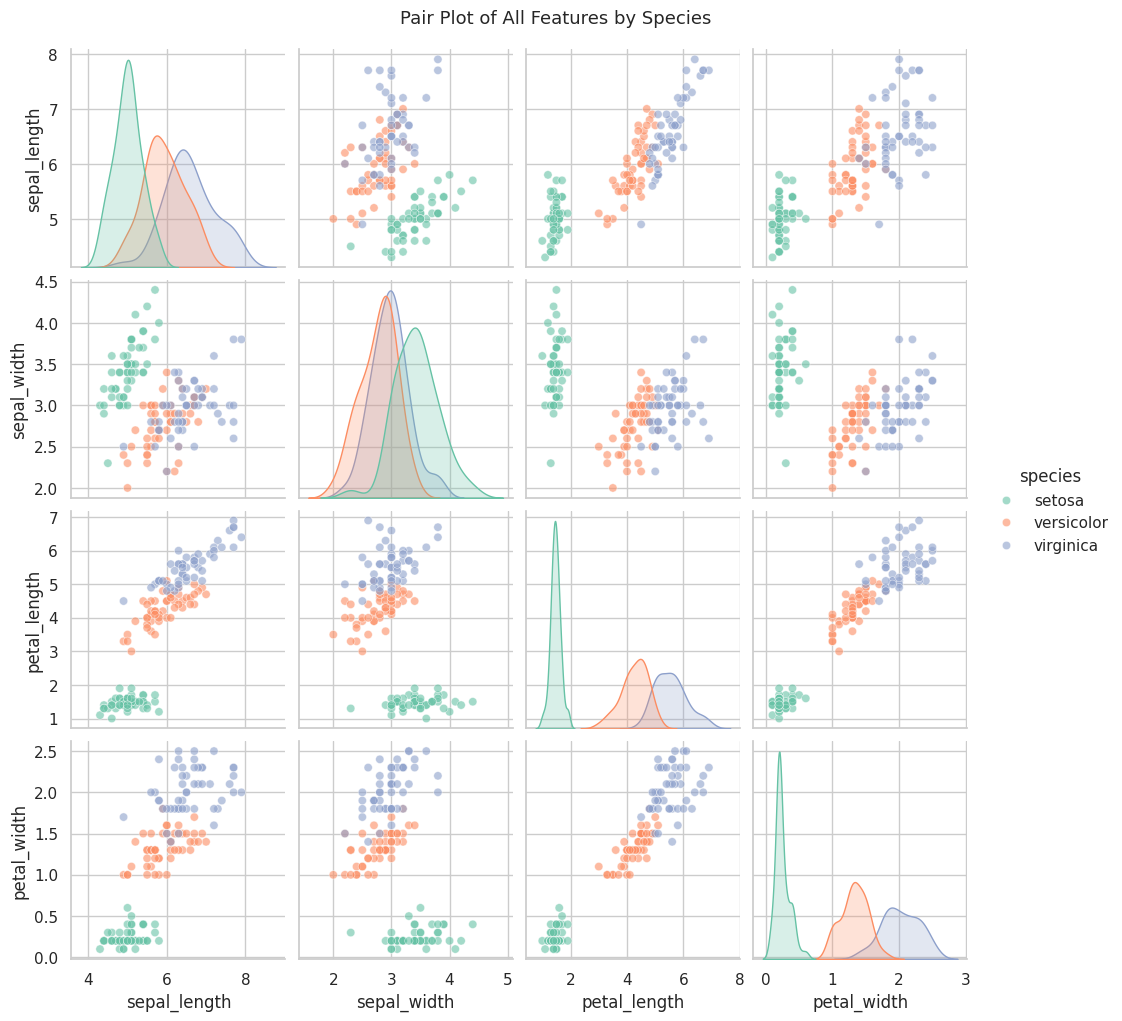

In [11]:
# Pair plot — all feature combinations at once
sns.pairplot(df, hue='species', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of All Features by Species', y=1.02, fontsize=13)
plt.show()

### 3b. Histogram — Feature Distributions

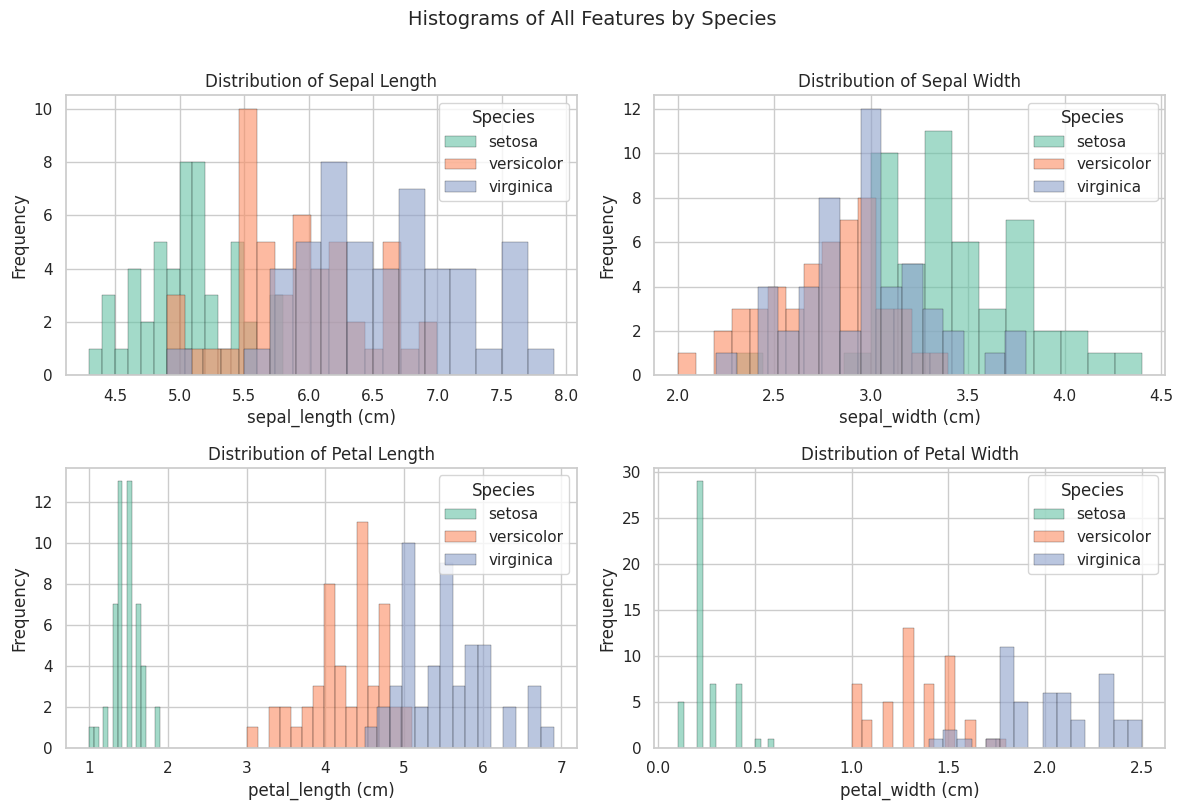

In [12]:
# Histogram for each numeric feature
numeric_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    for species in df['species'].unique():
        subset = df[df['species'] == species][feature]
        axes[i].hist(subset, bins=15, alpha=0.6, label=species, edgecolor='black', linewidth=0.3)
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[i].set_xlabel(f'{feature} (cm)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(title='Species')

plt.suptitle('Histograms of All Features by Species', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3c. Box Plot — Outliers and Spread

/tmp/ipykernel_5829/2323924005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[i],
/tmp/ipykernel_5829/2323924005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[i],
/tmp/ipykernel_5829/2323924005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[i],
/tmp/ipykernel_5829/2323924005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

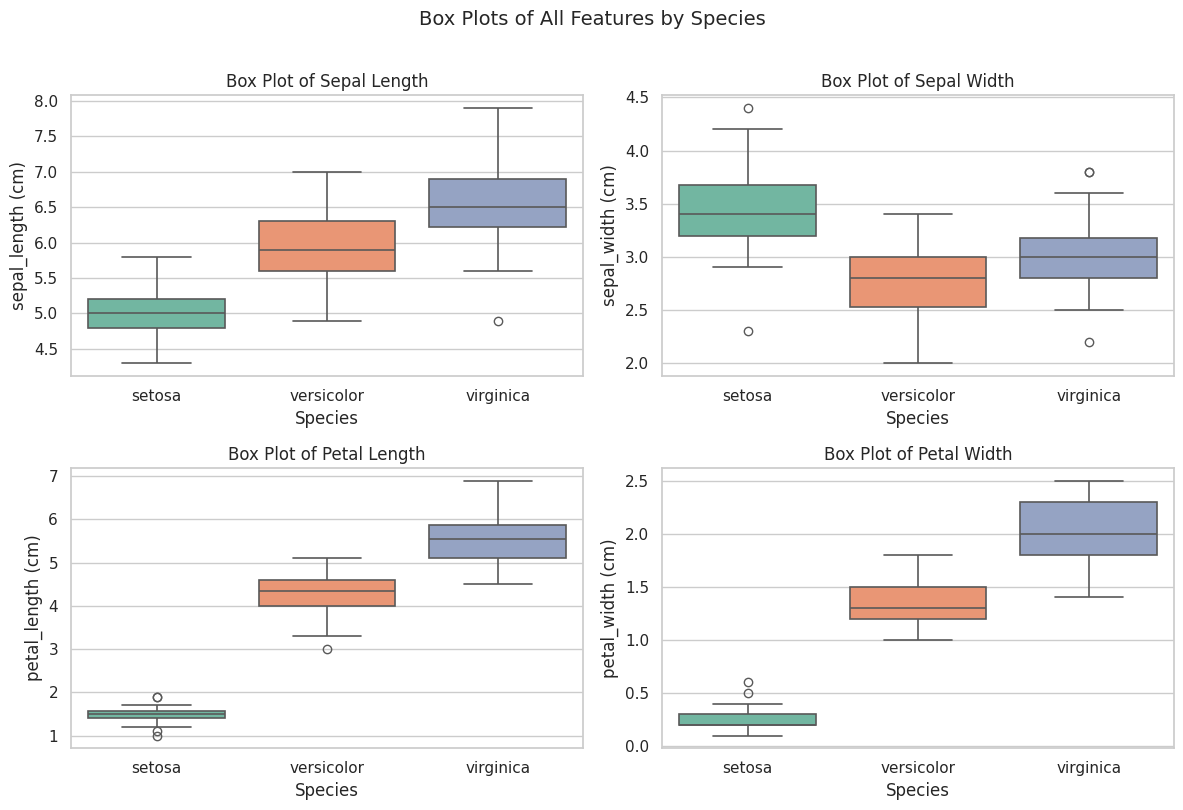

In [13]:
# Box plots for each feature grouped by species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(data=df, x='species', y=feature, ax=axes[i],
                palette='Set2', linewidth=1.2)
    axes[i].set_title(f'Box Plot of {feature.replace("_", " ").title()}')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(f'{feature} (cm)')

plt.suptitle('Box Plots of All Features by Species', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

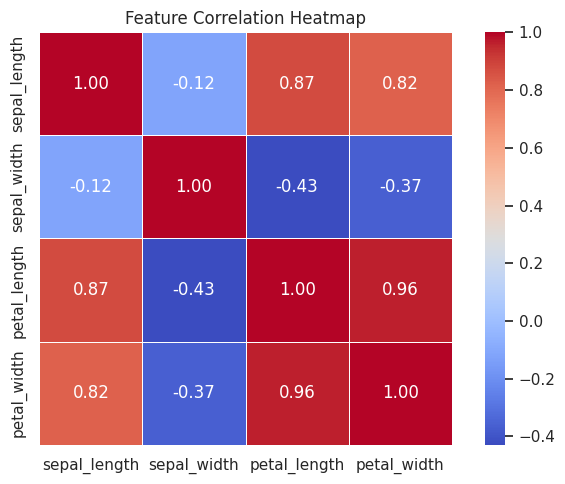

In [14]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Conclusion

**Key Insights from the Iris Dataset:**

1. **Petal features are more discriminative** than sepal features for separating species. Petal length and petal width show clear clustering by species.
2. **Iris setosa** is completely separable from the other two species based on petal measurements.
3. **Iris versicolor and Iris virginica** have some overlap, making them harder to distinguish.
4. **High correlation** exists between petal length and petal width (r ≈ 0.96), and also between petal length and sepal length (r ≈ 0.87).
5. **No missing values** were found — the dataset is clean and ready for modeling.
6. **Sepal width has the most outliers** (visible in box plots), especially for setosa.

These findings suggest that a classifier using petal features would achieve very high accuracy on this dataset.